# 08 — Hierarchical & Tiered Retrieval

**Tier:** RAG Design Patterns
**Estimated time:** 50 minutes
**Prerequisites:** 01 (Naive RAG), 02 (Retrieve-and-Rerank); curriculum notebooks 14, 22
**Priority:** 🟡 Important — flat top-k retrieval wastes context budget and drowns the answer in near-duplicate chunks; hierarchy + tiered rendering is how production context systems cut token use dramatically without losing recall. *If skipped, revisit when:* your RAG context is full of redundant chunks, or you're blowing the context/token budget on retrieval.
**Source material:** OpenViking (`retrieve/hierarchical_retriever.py`, `retrieve/intent_analyzer.py`, `retrieve/type_quota_recall.py`), https://github.com/volcengine/OpenViking — a production context database that replaces flat vector search with recursive directory retrieval and tiered (L0/L1/L2) context loading, reporting up to ~91% token reduction.

## What You'll Learn
- Why flat top-k retrieval wastes context budget, and how a **hierarchy** (category → document → chunk) fixes it
- **Recursive retrieval** with *convergence rounds* and *directory-dominance* — return a whole branch when it dominates, drill down when it doesn't
- **Intent-driven query planning**: expand one query into several typed sub-queries
- **Tiered rendering (L0/L1/L2)** with graceful degradation — full → summary → URI-only — to fit a token budget

## Why This Matters
Naive RAG (notebook 01) retrieves the top-k chunks by cosine similarity and pastes them into the prompt. At scale that means near-duplicate chunks from the same document, no sense of structure, and a context window spent on redundancy. OpenViking's answer — and today's notebook — is to organize knowledge as a tree, retrieve it recursively, and render it at whatever level of detail the token budget affords. This is the concrete mechanism behind "load less, answer the same."

## From a pile of pages to a filing cabinet

Naive RAG treats your corpus as **one flat pile of chunks**. Ask a question, embed it, grab the 5 nearest chunks. If four of them are near-duplicates from the same spec sheet, you've spent 80% of your context budget learning the same fact four times.

A **filing cabinet** is organized: drawers (categories) → folders (documents) → pages (chunks). To answer a question you don't read every page — you find the right *drawer*, then the right *folder*, then the right *pages*. Two ideas make this work:

- **Recursive retrieval.** Score the top level, descend into the best branches, repeat. Stop when the top results stop changing (**convergence**). If a whole drawer is clearly the answer and no single page beats it, return the drawer's overview instead of drilling (**directory-dominance**) — cheaper and less redundant.
- **Tiered rendering (L0/L1/L2).** Not every retrieved item deserves full text. Render the best hits in **full (L2)**, the next ones as a **summary (L1)**, and the long tail as just a **URI/pointer (L0)** the agent can expand on demand. Under a tight budget, gracefully **degrade** lower-ranked items instead of dropping recall entirely.

We'll build all of this over the Helios Robotics corpus, whose filenames already encode a category (`spec_`, `incident_`, `proc_`, …) — a ready-made two-level hierarchy.

> Offline note: this notebook prefers real `ragkit` (MiniLM) embeddings but falls back to a deterministic character-n-gram vector when the model can't be fetched, so it always runs. The *mechanics* — hierarchy, convergence, dominance, tiering — are identical either way.

In [1]:
import sys, re, time
from pathlib import Path
from collections import defaultdict
import numpy as np

# Reach the repo root so we can import ragkit and read data/corpus.
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "ragkit").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from ragkit.data import load_corpus, chunk_text

docs = load_corpus()
print(f"Loaded {len(docs)} documents across categories:",
      sorted({d['category'] for d in docs}))

# --- Offline-safe embedding: try real MiniLM, else a deterministic n-gram vector ---
def _ngram_vec(text, dim=768):
    v = np.zeros(dim, dtype=np.float32)
    t = re.sub(r"\s+", " ", text.lower())
    for i in range(len(t) - 2):
        v[hash(t[i:i+3]) % dim] += 1.0
    n = np.linalg.norm(v)
    return v / n if n else v

def make_embedder():
    try:
        from ragkit.embeddings import embed
        _ = embed(["probe"])              # force the model to load (or fail) now
        return "ragkit-MiniLM", (lambda xs: np.asarray(embed(list(xs)), dtype=np.float32))
    except Exception as e:
        print(f"(real embeddings unavailable: {type(e).__name__}; using n-gram fallback)")
        return "ngram-fallback", (lambda xs: np.vstack([_ngram_vec(x) for x in xs]))

EMBED_KIND, embed_texts = make_embedder()

def cosine(a, b):
    return float(a @ b)   # vectors are L2-normalized, so dot == cosine

print("Embedder:", EMBED_KIND)

Loaded 17 documents across categories: ['faq', 'incident', 'proc', 'project', 'spec', 'team']


(real embeddings unavailable: ProxyError; using n-gram fallback)
Embedder: ngram-fallback


## Build the tree: category → document → chunk

We chunk every document, embed the chunks, then build node vectors bottom-up: a **document** vector is the mean (centroid) of its chunk vectors; a **category** vector is the centroid of its document vectors. A centroid is a cheap, honest summary of "what this branch is about" — good enough to decide whether to descend into it.

In [2]:
# Leaf level: chunks with provenance.
chunks = []   # each: {text, source, category, doc_id, chunk_id}
for d in docs:
    for i, ch in enumerate(chunk_text(d["text"], chunk_size=90, overlap=20)):
        chunks.append({"text": ch, "source": d["source"], "category": d["category"],
                       "doc_id": d["source"], "chunk_id": i})

chunk_vecs = embed_texts([c["text"] for c in chunks])
for c, v in zip(chunks, chunk_vecs):
    c["vec"] = v

# Document nodes: centroid of their chunk vectors.
docs_by_id = defaultdict(list)
for idx, c in enumerate(chunks):
    docs_by_id[c["doc_id"]].append(idx)
doc_nodes = {}
for doc_id, idxs in docs_by_id.items():
    vec = np.mean([chunks[i]["vec"] for i in idxs], axis=0)
    vec = vec / (np.linalg.norm(vec) or 1.0)
    doc_nodes[doc_id] = {"category": chunks[idxs[0]]["category"], "chunk_idxs": idxs, "vec": vec}

# Category nodes: centroid of their document vectors.
cats_by_name = defaultdict(list)
for doc_id, node in doc_nodes.items():
    cats_by_name[node["category"]].append(doc_id)
cat_nodes = {}
for cat, doc_ids in cats_by_name.items():
    vec = np.mean([doc_nodes[d]["vec"] for d in doc_ids], axis=0)
    vec = vec / (np.linalg.norm(vec) or 1.0)
    cat_nodes[cat] = {"doc_ids": doc_ids, "vec": vec}

print(f"Tree: {len(cat_nodes)} categories -> {len(doc_nodes)} documents -> {len(chunks)} chunks")

Tree: 6 categories -> 17 documents -> 83 chunks


## Part 1 — The flat baseline (and its redundancy problem)

First, plain top-k over every chunk — notebook 01's naive RAG. Watch how many of the top hits come from the *same document*: that's context budget spent on redundancy.

In [3]:
QUERY = "What controller does the HeliosArm V2 need and what firmware version?"
qv = embed_texts([QUERY])[0]

flat_scores = np.array([cosine(qv, c["vec"]) for c in chunks])
flat_topk = np.argsort(-flat_scores)[:5]

print(f"Query: {QUERY}\n")
print("Flat top-5 chunks:")
seen = defaultdict(int)
for rank, i in enumerate(flat_topk, 1):
    seen[chunks[i]["source"]] += 1
    print(f"  {rank}. {chunks[i]['source']:32s} chunk#{chunks[i]['chunk_id']}  score={flat_scores[i]:.3f}")
dupe_sources = {s: n for s, n in seen.items() if n > 1}
print("\nDocuments appearing more than once in top-5:", dupe_sources or "none")

Query: What controller does the HeliosArm V2 need and what firmware version?

Flat top-5 chunks:
  1. faq_general.txt                  chunk#0  score=0.577
  2. faq_software.txt                 chunk#0  score=0.500
  3. spec_controller_hc400.txt        chunk#0  score=0.499
  4. faq_software.txt                 chunk#3  score=0.496
  5. faq_general.txt                  chunk#1  score=0.496

Documents appearing more than once in top-5: {'faq_general.txt': 2, 'faq_software.txt': 2}


## Part 2 — Recursive retrieval with convergence & directory-dominance

Now retrieve *through the tree*. Starting at the category level we keep the best branches, descend into their documents, keep the best of those, then collect chunks — recording the **trajectory** (which nodes we visited) so retrieval is debuggable, exactly as OpenViking logs directory paths.

Two controls from `hierarchical_retriever.py`:
- **Directory-dominance:** if a branch's own centroid beats its best child by a ratio, we return the branch's *overview* instead of drilling into it — one summary node instead of many redundant leaves.
- **Convergence:** we widen the beam round by round and stop once the collected top-k chunk set stops changing (`MAX_CONVERGENCE_ROUNDS`).

In [4]:
DOMINANCE_RATIO = 1.05     # a parent must beat its best child by this factor to "dominate"
MAX_CONVERGENCE_ROUNDS = 3
BEAM = 3                   # branches kept per level
MAX_PER_DOC = 2            # <= this many chunks from any one document (anti-redundancy)

def hierarchical_retrieve(qv, k=5):
    trajectory = []
    cat_scored = sorted(cat_nodes.items(), key=lambda kv: -cosine(qv, kv[1]["vec"]))
    collected, dominated = [], []
    prev_top = None
    for rnd in range(1, MAX_CONVERGENCE_ROUNDS + 1):
        beam = min(BEAM + rnd - 1, len(cat_scored))   # widen the beam each round
        cand, dominated, per_doc = [], [], defaultdict(int)
        for cat, cnode in cat_scored[:beam]:
            cat_score = cosine(qv, cnode["vec"])
            doc_scored = sorted(cnode["doc_ids"], key=lambda d: -cosine(qv, doc_nodes[d]["vec"]))
            best_doc_score = cosine(qv, doc_nodes[doc_scored[0]]["vec"])
            # Directory-dominance: a whole category so on-topic it beats its best doc
            # earns an OVERVIEW node (added alongside chunks, not instead of them).
            dom = cat_score >= best_doc_score * DOMINANCE_RATIO
            trajectory.append(f"category:{cat} ({cat_score:.3f}) best_doc={best_doc_score:.3f}"
                              + ("  [DOMINATES -> +overview]" if dom else ""))
            if dom:
                dominated.append(("category", cat, round(cat_score, 3)))
            # Drill into the top docs, but cap chunks per document to kill redundancy.
            for doc_id in doc_scored[:beam]:
                for ci in sorted(doc_nodes[doc_id]["chunk_idxs"], key=lambda c: -cosine(qv, chunks[c]["vec"])):
                    if per_doc[doc_id] < MAX_PER_DOC:
                        cand.append(ci); per_doc[doc_id] += 1
        collected = sorted(set(cand), key=lambda ci: -cosine(qv, chunks[ci]["vec"]))[:k]
        top_sig = tuple(collected)
        trajectory.append(f"[round {rnd}] beam={beam} -> {len(collected)} chunks (<= {MAX_PER_DOC}/doc)")
        if top_sig == prev_top:
            trajectory.append(f"[converged after round {rnd}]")
            break
        prev_top = top_sig
    return collected, dominated, trajectory

hits, dominated, traj = hierarchical_retrieve(qv, k=5)
print("Trajectory:")
for step in traj:
    print("  " + step)
print("\nRetrieved chunks (<= 2 per document, deduped across the tree):")
per_doc_seen = defaultdict(int)
for rank, ci in enumerate(hits, 1):
    per_doc_seen[chunks[ci]["source"]] += 1
    print(f"  {rank}. {chunks[ci]['source']:32s} chunk#{chunks[ci]['chunk_id']}  score={cosine(qv, chunks[ci]['vec']):.3f}")
print("\nMax chunks from any one document:", max(per_doc_seen.values()), f"(flat top-5 had up to {max(seen.values())})")
print("Dominant overview nodes:", dominated or "none")

Trajectory:
  category:faq (0.543) best_doc=0.531
  category:proc (0.426) best_doc=0.402  [DOMINATES -> +overview]
  category:incident (0.425) best_doc=0.423
  [round 1] beam=3 -> 5 chunks (<= 2/doc)
  category:faq (0.543) best_doc=0.531
  category:proc (0.426) best_doc=0.402  [DOMINATES -> +overview]
  category:incident (0.425) best_doc=0.423
  category:spec (0.399) best_doc=0.380
  [round 2] beam=4 -> 5 chunks (<= 2/doc)
  category:faq (0.543) best_doc=0.531
  category:proc (0.426) best_doc=0.402  [DOMINATES -> +overview]
  category:incident (0.425) best_doc=0.423
  category:spec (0.399) best_doc=0.380
  category:team (0.389) best_doc=0.365  [DOMINATES -> +overview]
  [round 3] beam=5 -> 5 chunks (<= 2/doc)
  [converged after round 3]

Retrieved chunks (<= 2 per document, deduped across the tree):
  1. faq_general.txt                  chunk#0  score=0.577
  2. faq_software.txt                 chunk#0  score=0.500
  3. spec_controller_hc400.txt        chunk#0  score=0.499
  4. faq_sof

## Part 3 — Intent-driven query planning

A single query often bundles several *intents*. OpenViking's `intent_analyzer.py` uses an LLM to turn the session context into a **plan of typed sub-queries** (memory vs. resources vs. skills). Here we build a lightweight, offline planner that splits a compound query into typed sub-queries and retrieves each separately, then merges — so *"what controller AND what firmware"* fans out into two focused retrievals instead of one blurred average.

(An LLM planner is a drop-in upgrade: swap `plan_queries` for a guarded `ask()` call that returns the same list of `(type, subquery)` pairs.)

In [5]:
ASPECTS = {
    "hardware": ["controller", "part", "payload", "gripper", "base", "motor"],
    "firmware": ["firmware", "version", "software", "release", "heliosmaster"],
    "procedure": ["install", "replace", "commission", "calibrate", "procedure"],
    "incident": ["failure", "error", "fault", "incident", "downtime"],
}

def plan_queries(query):
    # Rule-based intent split: emit a typed sub-query per aspect whose keywords
    # appear, always including a generic pass so nothing is lost.
    q = query.lower()
    plan = [("general", query)]
    for atype, kws in ASPECTS.items():
        if any(kw in q for kw in kws):
            focus = " ".join(kw for kw in kws if kw in q)
            plan.append((atype, f"{query} :: focus on {focus}"))
    return plan

def planned_retrieve(query, k_each=3):
    merged = {}
    for atype, subq in plan_queries(query):
        sv = embed_texts([subq])[0]
        hits, _, _ = hierarchical_retrieve(sv, k=k_each)
        for ci in hits:
            merged[ci] = max(merged.get(ci, -1), cosine(sv, chunks[ci]["vec"]))
    return sorted(merged, key=lambda ci: -merged[ci])

plan = plan_queries(QUERY)
print("Query plan:")
for atype, subq in plan:
    print(f"  [{atype}] {subq}")
planned_hits = planned_retrieve(QUERY, k_each=3)
print(f"\nMerged {len(planned_hits)} unique chunks from {len(plan)} typed sub-queries:")
for ci in planned_hits[:6]:
    print(f"  {chunks[ci]['source']:32s} chunk#{chunks[ci]['chunk_id']}")

Query plan:
  [general] What controller does the HeliosArm V2 need and what firmware version?
  [hardware] What controller does the HeliosArm V2 need and what firmware version? :: focus on controller
  [firmware] What controller does the HeliosArm V2 need and what firmware version? :: focus on firmware version

Merged 4 unique chunks from 3 typed sub-queries:
  faq_general.txt                  chunk#0
  spec_controller_hc400.txt        chunk#0
  faq_software.txt                 chunk#3
  faq_software.txt                 chunk#0


## Part 4 — Tiered rendering (L0/L1/L2) with graceful degradation

Retrieval found the right chunks; now we have to *fit them in the budget*. OpenViking's `type_quota_recall.py` renders a bounded block that degrades **full → summary → URI-only**. We give the top hits full text (L2), mid hits a one-line summary (L1), and the tail just a citable URI (L0). Instead of hard-dropping lower-ranked context (losing recall), we **keep it at a cheaper tier**.

In [6]:
def est_tokens(text):
    return max(1, len(text) // 4)        # ~4 chars/token, good enough for budgeting

def summarize(text, n_words=18):
    words = text.split()
    return " ".join(words[:n_words]) + (" …" if len(words) > n_words else "")

def uri_of(ci):
    return f"viking://helios/{chunks[ci]['category']}/{chunks[ci]['source']}#chunk{chunks[ci]['chunk_id']}"

def render_tiered(hit_idxs, token_budget, full_n=2, summ_n=4):
    # Top `full_n` -> L2 (full), next `summ_n` -> L1 (summary), rest -> L0 (URI),
    # but degrade earlier if the budget runs out.
    blocks, used, tiers = [], 0, {"L2": 0, "L1": 0, "L0": 0}
    for rank, ci in enumerate(hit_idxs):
        if rank < full_n:
            tier, body = "L2", chunks[ci]["text"]
        elif rank < full_n + summ_n:
            tier, body = "L1", summarize(chunks[ci]["text"])
        else:
            tier, body = "L0", uri_of(ci)
        cost = est_tokens(body)
        if used + cost > token_budget:       # budget pressure -> degrade to L0
            tier, body = "L0", uri_of(ci)
            cost = est_tokens(body)
            if used + cost > token_budget:
                break
        blocks.append((tier, uri_of(ci), body)); used += cost; tiers[tier] += 1
    return blocks, used, tiers

# Flat baseline cost: every top hit rendered in full.
flat_full_tokens = sum(est_tokens(chunks[i]["text"]) for i in flat_topk)

BUDGET = 220
blocks, tiered_tokens, tier_counts = render_tiered(planned_hits, token_budget=BUDGET)

print(f"Flat top-5, all full text : {flat_full_tokens} tokens")
print(f"Tiered render (budget {BUDGET}) : {tiered_tokens} tokens   tiers={tier_counts}\n")
for tier, uri, body in blocks:
    shown = body if tier != "L2" else summarize(body, 12)
    print(f"  [{tier}] {uri}\n        {shown}")

Flat top-5, all full text : 710 tokens
Tiered render (budget 220) : 202 tokens   tiers={'L2': 1, 'L1': 2, 'L0': 1}

  [L2] viking://helios/faq/faq_general.txt#chunk0
        HELIOS ROBOTICS — FREQUENTLY ASKED QUESTIONS Document: General FAQ Last Updated: 2024-10-01 …
  [L0] viking://helios/spec/spec_controller_hc400.txt#chunk0
        viking://helios/spec/spec_controller_hc400.txt#chunk0
  [L1] viking://helios/faq/faq_software.txt#chunk3
        FW-M1-1.5.1 and run a calibration cycle via HeliosFleet → Unit → Battery → Run Calibration Cycle. Q: How …
  [L1] viking://helios/faq/faq_software.txt#chunk0
        HELIOS ROBOTICS — FREQUENTLY ASKED QUESTIONS Document: Software & Controller FAQ Last Updated: 2024-10-15 Q: What version of …


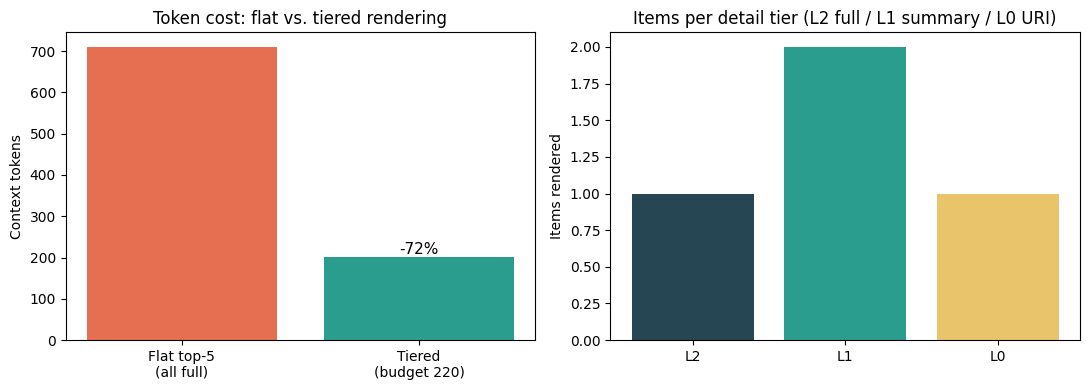

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Left: token cost, flat-full vs tiered.
ax1.bar(["Flat top-5\n(all full)", f"Tiered\n(budget {BUDGET})"],
        [flat_full_tokens, tiered_tokens], color=["#e76f51", "#2a9d8f"])
ax1.set_ylabel("Context tokens")
ax1.set_title("Token cost: flat vs. tiered rendering")
reduction = 100 * (1 - tiered_tokens / flat_full_tokens) if flat_full_tokens else 0
ax1.text(1, tiered_tokens, f"-{reduction:.0f}%", ha="center", va="bottom", fontsize=11)

# Right: how many items landed in each tier.
ax2.bar(list(tier_counts.keys()), list(tier_counts.values()), color=["#264653", "#2a9d8f", "#e9c46a"])
ax2.set_ylabel("Items rendered")
ax2.set_title("Items per detail tier (L2 full / L1 summary / L0 URI)")

plt.tight_layout(); plt.show()

*Tiered rendering keeps the same retrieved items but spends full-text budget only on the top hits, degrading the rest to summaries and URIs — recall is preserved while token cost drops sharply. This is the mechanism behind OpenViking's large token-reduction numbers.*

## Exercises

In [8]:
# Exercise 1 (Warm-up): tune the dominance ratio
# Task: set DOMINANCE_RATIO to 0.95 and re-run Part 2; observe how many branches
#       now return an overview node instead of drilling to chunks, and why.
# Hint: a lower ratio makes it *easier* for a parent to "dominate" its children.

# YOUR CODE HERE

In [9]:
# Exercise 2 (Apply): add an L1.5 tier
# Task: insert a tier between L1 (summary) and L0 (URI): a two-sentence excerpt.
#       Render ranks 6-8 at this new tier and show the token cost change.
# Hint: copy render_tiered and add a branch that takes the first 2 sentences.

# YOUR CODE HERE

In [10]:
# Exercise 3 (Extend): budget sweep
# Task: run render_tiered across BUDGET in [80, 140, 220, 400] and plot tokens-used
#       and #L2 items vs budget — the classic recall/cost trade-off curve.
# Hint: call render_tiered in a loop and collect (budget, used, tiers['L2']).

# YOUR CODE HERE

<details>
<summary>Solutions (click to expand)</summary>

```python
# Exercise 1
DOMINANCE_RATIO = 0.95
hits, dominated, traj = hierarchical_retrieve(qv, k=5)
print("Dominant overviews now:", dominated)   # more categories return an overview

# Exercise 2
def render_tiered_15(hit_idxs, token_budget, full_n=2, summ_n=2, excerpt_n=3):
    blocks, used = [], 0
    for rank, ci in enumerate(hit_idxs):
        if rank < full_n:
            body = chunks[ci]["text"]
        elif rank < full_n + summ_n:
            body = summarize(chunks[ci]["text"])
        elif rank < full_n + summ_n + excerpt_n:
            body = " ".join(re.split(r"(?<=[.!?]) ", chunks[ci]["text"])[:2])  # L1.5
        else:
            body = uri_of(ci)
        cost = est_tokens(body)
        if used + cost > token_budget:
            break
        blocks.append((rank, body)); used += cost
    return blocks, used

print(render_tiered_15(planned_hits, 260)[1], "tokens")

# Exercise 3
import matplotlib.pyplot as plt
xs, used_ys, l2_ys = [], [], []
for b in [80, 140, 220, 400]:
    _, u, t = render_tiered(planned_hits, token_budget=b)
    xs.append(b); used_ys.append(u); l2_ys.append(t["L2"])
fig, ax = plt.subplots()
ax.plot(xs, used_ys, "o-", label="tokens used")
ax.plot(xs, l2_ys, "s-", label="# full (L2) items")
ax.set_xlabel("budget"); ax.legend(); plt.show()
```
</details>

## Key Takeaways
- **Flat top-k wastes budget on redundancy.** Structuring the corpus as category → document → chunk lets retrieval descend to the right branch instead of averaging over everything.
- **Recursive retrieval = convergence + dominance.** Widen the beam until the top-k stabilizes; return a branch's overview when it dominates its children, instead of drilling into redundant leaves.
- **Intent planning fans one query into typed sub-queries**, so a compound question is answered by several focused retrievals rather than one blurred average.
- **Tiered rendering (L0/L1/L2) trades detail for budget gracefully** — full text for the best hits, summaries for the middle, URIs for the tail — preserving recall while cutting tokens.
- The retrieval **trajectory** (which nodes were visited) makes hierarchical retrieval debuggable, unlike an opaque flat similarity scan.

## What's Next
This closes the RAG-patterns tier with the retrieval strategy behind production context databases; from here, notebook 22c takes the same "structure your memory, load it in tiers" idea into **agent memory lifecycle** — what to keep hot, what to let go cold, and how to extract memories from a raw session.